In [6]:
# At the beginning of Task 2
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load saved data
close_prices_filled = pd.read_csv('C:/Users/hp/portfolio-optimization/data/processedclose_prices.csv', index_col='Date', parse_dates=True)
returns = pd.read_csv('C:/Users/hp/portfolio-optimization/data/processed/returns.csv', index_col='Date', parse_dates=True)

print(f"✅ Data loaded from CSV:")
print(f"   Close prices: {close_prices_filled.shape}")
print(f"   Returns: {returns.shape}")
print("\nFirst 5 rows:")
print(close_prices_filled.head())

✅ Data loaded from CSV:
   Close prices: (2888, 3)
   Returns: (2887, 3)

First 5 rows:
                 TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405392  169.687866
2015-01-05  14.006000  59.577942  166.623337
2015-01-06  14.085333  59.750420  165.053894
2015-01-07  14.063333  59.786339  167.110718
2015-01-08  14.041333  59.692936  170.076065


Training data: 2015-01-02 00:00:00 to 2024-12-31 00:00:00
Training set size: 2516 days
Test data: 2025-01-02 00:00:00 to 2026-06-29 00:00:00
Test set size: 372 days


ConversionError: Failed to convert value(s) to axis units: '2024-12-31'

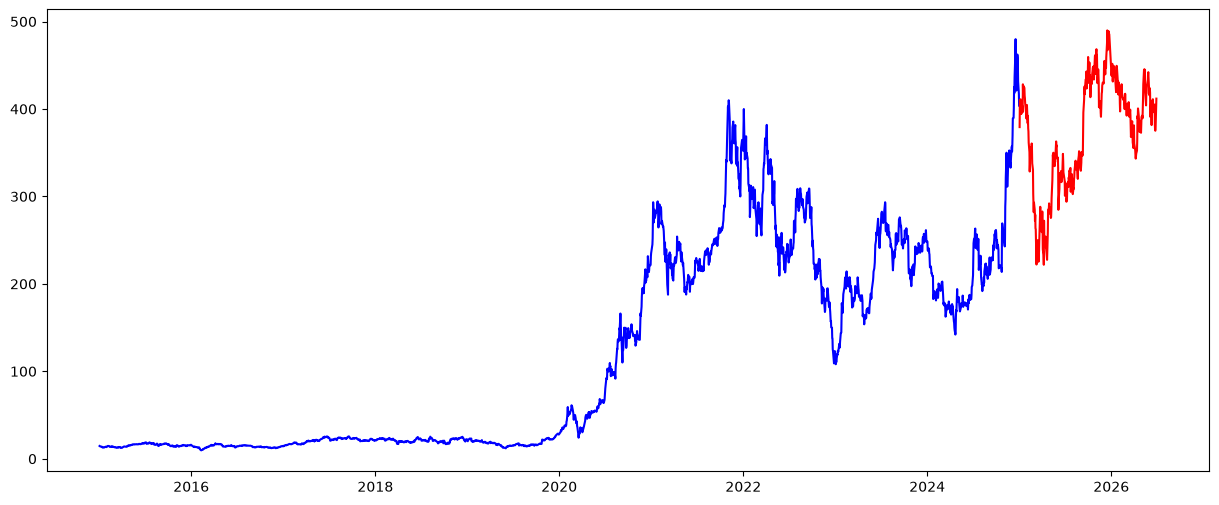

In [8]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
# Prepare data for modeling - focusing on TSLA
tsla_data = close_prices_filled['TSLA'].copy()

# Split data chronologically
train_end = '2024-12-31'  # Train on 2015-2024
test_start = '2025-01-01'  # Test on 2025-2026

train_data = tsla_data[:train_end]
test_data = tsla_data[test_start:]

print(f"Training data: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Training set size: {len(train_data)} days")
print(f"Test data: {test_data.index[0]} to {test_data.index[-1]}")
print(f"Test set size: {len(test_data)} days")

# Visualize train-test split
plt.figure(figsize=(15, 6))
plt.plot(train_data.index, train_data, label='Training Data', color='blue', linewidth=1.5)
plt.plot(test_data.index, test_data, label='Test Data', color='red', linewidth=1.5)
plt.axvline(x=train_end, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Train-Test Split')
plt.title('TSLA - Training and Test Data Split', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

# Normalize/scale data for LSTM
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data.values.reshape(-1, 1))
scaled_test = scaler.transform(test_data.values.reshape(-1, 1))

print("Data scaling complete for LSTM model")

Checking stationarity of TSLA training data...
ADF Statistic: -0.5814
p-value: 0.8751
Data is not stationary. Taking first difference...
Checking stationarity of differenced data...
ADF Statistic: -9.7363
p-value: 0.0000


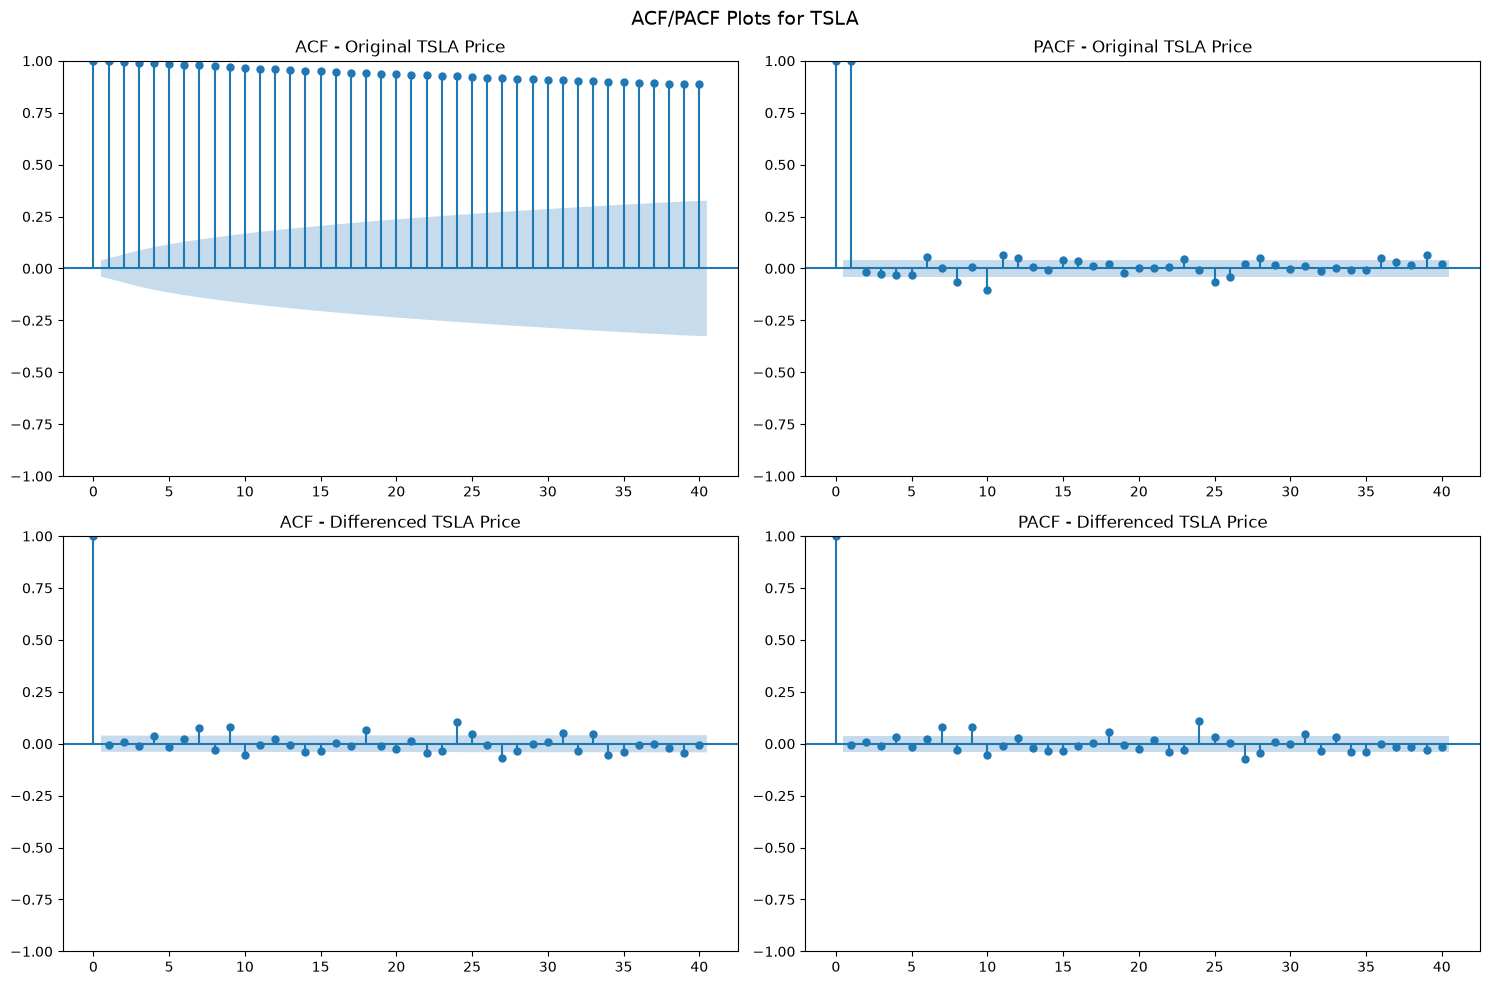


=== AUTO-ARIMA PARAMETER SELECTION ===
Running auto_arima... (this may take a few minutes)
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.38 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.485 seconds

Best ARIMA parameters:
Order: (0, 1, 0)
Seasonal order: (0, 0, 0, 0)
AIC: 16368.11

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2516
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8183.054
Date:                Mon, 06 Jul 2026   AIC                          16368.109
Time:                        22

c:\Users\hp\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hp\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hp\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hp\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer ind

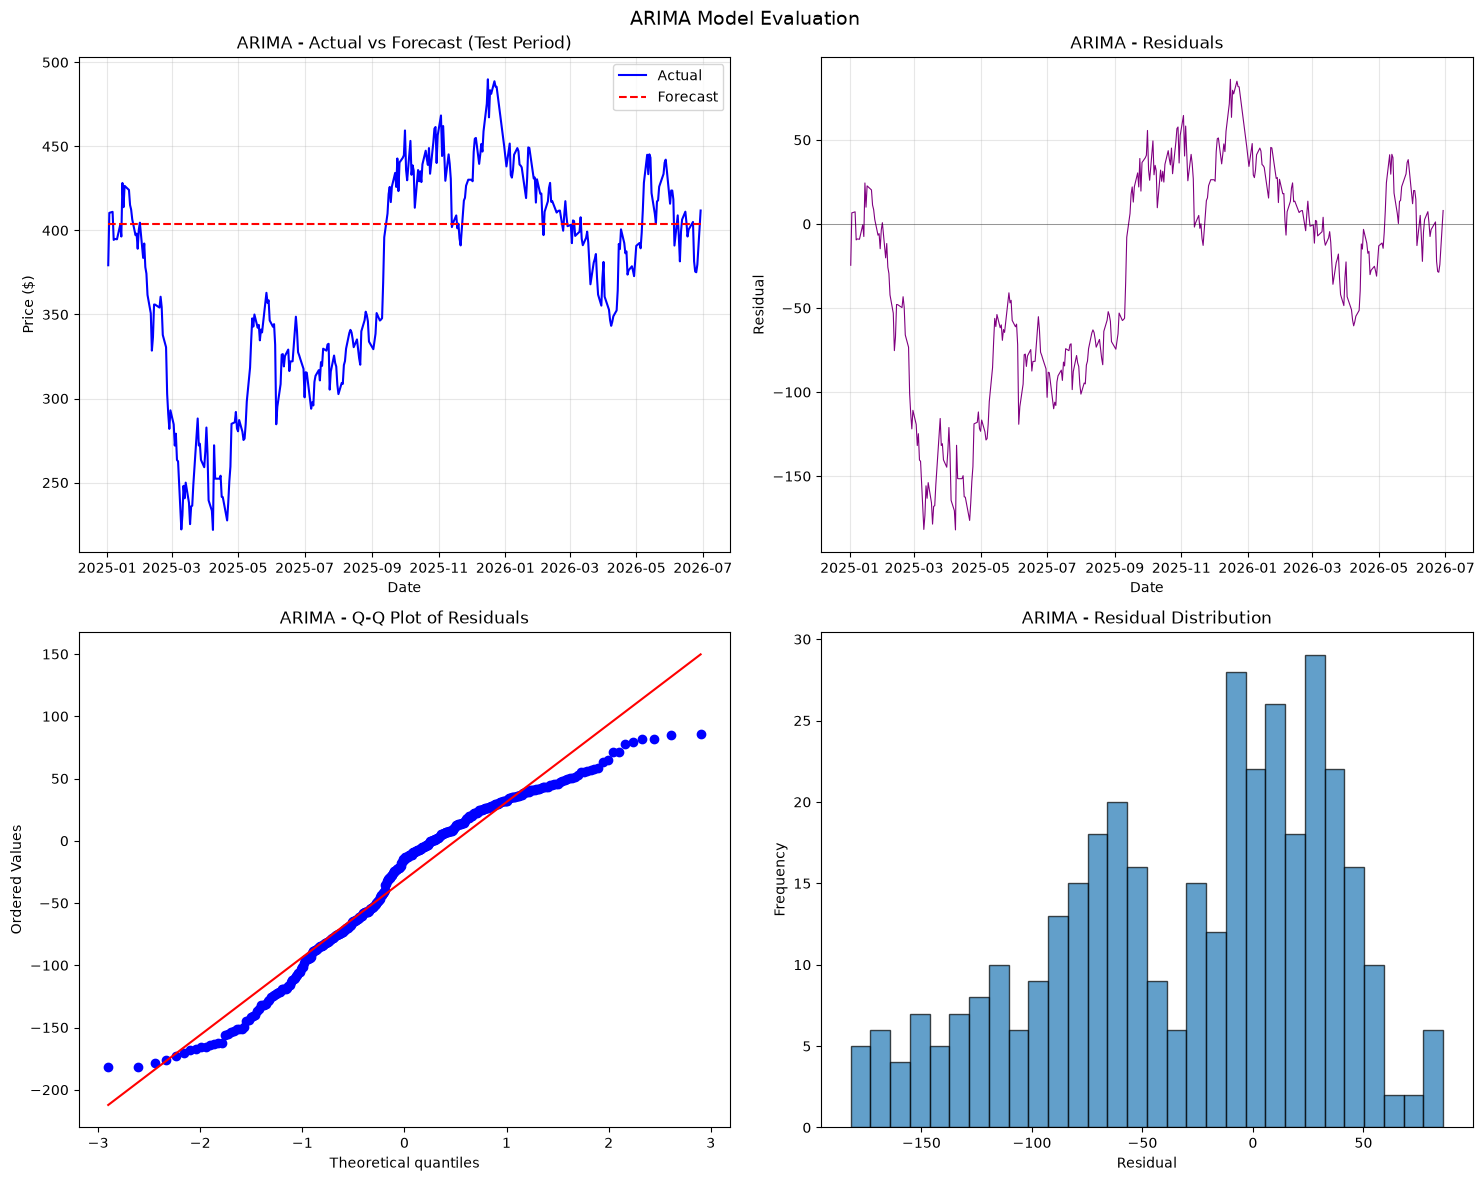

In [9]:
# Import ARIMA libraries
from pmdarima import auto_arima
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Check stationarity of training data
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    return result[1] <= 0.05

print("Checking stationarity of TSLA training data...")
is_stationary = check_stationarity(train_data)

# If not stationary, difference the data
if not is_stationary:
    print("Data is not stationary. Taking first difference...")
    train_diff = train_data.diff().dropna()
    print("Checking stationarity of differenced data...")
    check_stationarity(train_diff)

# ACF and PACF plots for order selection
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original series
plot_acf(train_data.dropna(), ax=axes[0, 0], lags=40)
axes[0, 0].set_title('ACF - Original TSLA Price')
plot_pacf(train_data.dropna(), ax=axes[0, 1], lags=40)
axes[0, 1].set_title('PACF - Original TSLA Price')

# Differenced series
if not is_stationary:
    plot_acf(train_diff.dropna(), ax=axes[1, 0], lags=40)
    axes[1, 0].set_title('ACF - Differenced TSLA Price')
    plot_pacf(train_diff.dropna(), ax=axes[1, 1], lags=40)
    axes[1, 1].set_title('PACF - Differenced TSLA Price')

plt.suptitle('ACF/PACF Plots for TSLA', fontsize=14)
plt.tight_layout()
plt.savefig('acf_pacf_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Use auto_arima to find optimal parameters
print("\n=== AUTO-ARIMA PARAMETER SELECTION ===")
print("Running auto_arima... (this may take a few minutes)")

auto_model = auto_arima(
    train_data,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,  # Since we're using ARIMA not SARIMA
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    n_fits=50,
    information_criterion='aic'
)

print("\nBest ARIMA parameters:")
print(f"Order: {auto_model.order}")
print(f"Seasonal order: {auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.2f}")

# Fit ARIMA model with best parameters
best_order = auto_model.order
arima_model = ARIMA(train_data, order=best_order)
arima_fit = arima_model.fit()

print("\nARIMA Model Summary:")
print(arima_fit.summary())

# Generate forecasts for test period
arima_forecast = arima_fit.forecast(steps=len(test_data))

# Create forecast DataFrame
arima_results = pd.DataFrame({
    'Actual': test_data.values,
    'Forecast': arima_forecast.values
}, index=test_data.index)

# Calculate residuals
arima_residuals = arima_results['Actual'] - arima_results['Forecast']

# Plot ARIMA results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Actual vs Forecast
axes[0, 0].plot(arima_results.index, arima_results['Actual'], 
                label='Actual', color='blue', linewidth=1.5)
axes[0, 0].plot(arima_results.index, arima_results['Forecast'], 
                label='Forecast', color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('ARIMA - Actual vs Forecast (Test Period)', fontsize=12)
axes[0, 0].set_xlabel('Date', fontsize=10)
axes[0, 0].set_ylabel('Price ($)', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Residuals
axes[0, 1].plot(arima_results.index, arima_residuals, color='purple', linewidth=0.8)
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.5)
axes[0, 1].set_title('ARIMA - Residuals', fontsize=12)
axes[0, 1].set_xlabel('Date', fontsize=10)
axes[0, 1].set_ylabel('Residual', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot of residuals
from scipy import stats
stats.probplot(arima_residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('ARIMA - Q-Q Plot of Residuals', fontsize=12)

# Histogram of residuals
axes[1, 1].hist(arima_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('ARIMA - Residual Distribution', fontsize=12)
axes[1, 1].set_xlabel('Residual', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)

plt.suptitle('ARIMA Model Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('arima_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# =================================================
# SCALE DATA FOR LSTM (Run this before LSTM)
# =================================================

from sklearn.preprocessing import MinMaxScaler

# Get TSLA data
tsla_data = close_prices_filled['TSLA'].copy()

# Split data
train_end = '2024-12-31'
test_start = '2025-01-01'

train_data = tsla_data[:train_end]
test_data = tsla_data[test_start:]

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data.values.reshape(-1, 1))
scaled_test = scaler.transform(test_data.values.reshape(-1, 1))

print(f"✅ Data scaled successfully!")
print(f"   Scaled train shape: {scaled_train.shape}")
print(f"   Scaled test shape: {scaled_test.shape}")
print(f"   Scaler saved for inverse transformation")

✅ Data scaled successfully!
   Scaled train shape: (2516, 1)
   Scaled test shape: (372, 1)
   Scaler saved for inverse transformation


Training data shape: (2456, 60, 1)
Testing data shape: (372, 60, 1)
LSTM Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

None

Training LSTM model...
Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - loss: 0.0046 - val_loss: 0.0036
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 0.0016 - val_loss: 0.0055
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0014 - val_loss: 0.0023
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 9.9979e-04 - val_loss: 0.0047
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - loss: 9.8770e-04 - val_loss: 0.0018
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 9/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - loss: 9.0359e-04 - val_loss: 0.0025
Epoch 10/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 7.4365e-04 - val_loss: 0.0022
Epoch 11/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 9.3290e-04 - val_loss: 0.

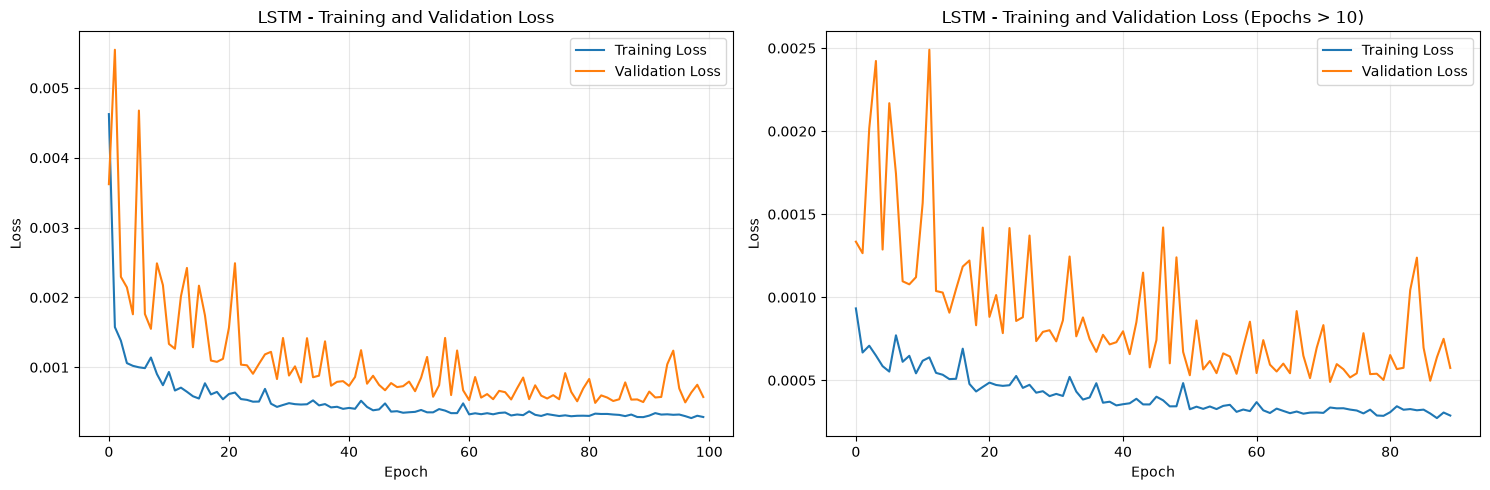

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


ValueError: Length of values (372) does not match length of index (312)

In [12]:
# Import TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Prepare data for LSTM
def create_sequences(data, window_size):
    """Create sequences for LSTM"""
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Set window size
window_size = 60

# Prepare training data
X_train, y_train = create_sequences(scaled_train, window_size)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# Prepare test data
# Use the last window_size points from training for the first prediction
test_sequences = scaled_train[-window_size:].tolist() + scaled_test.tolist()
X_test, y_test = create_sequences(np.array(test_sequences), window_size)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Build LSTM model
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

# Build and train model
lstm_model = build_lstm_model((window_size, 1))
print("LSTM Model Summary:")
print(lstm_model.summary())

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model
print("\nTraining LSTM model...")
history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=1.5)
axes[0].set_title('LSTM - Training and Validation Loss', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('Loss', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Training loss (zoomed)
axes[1].plot(history.history['loss'][10:], label='Training Loss', linewidth=1.5)
axes[1].plot(history.history['val_loss'][10:], label='Validation Loss', linewidth=1.5)
axes[1].set_title('LSTM - Training and Validation Loss (Epochs > 10)', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Generate LSTM predictions
lstm_predictions_scaled = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)

# Prepare actual values
# y_test is scaled, need to inverse transform
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Create results DataFrame
lstm_results = pd.DataFrame({
    'Actual': y_test_actual,
    'Forecast': lstm_predictions.flatten()
}, index=test_data.index[window_size:])

# Calculate residuals
lstm_residuals = lstm_results['Actual'] - lstm_results['Forecast']

# Plot LSTM results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Actual vs Forecast
axes[0, 0].plot(lstm_results.index, lstm_results['Actual'], 
                label='Actual', color='blue', linewidth=1.5)
axes[0, 0].plot(lstm_results.index, lstm_results['Forecast'], 
                label='Forecast', color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('LSTM - Actual vs Forecast (Test Period)', fontsize=12)
axes[0, 0].set_xlabel('Date', fontsize=10)
axes[0, 0].set_ylabel('Price ($)', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Residuals
axes[0, 1].plot(lstm_results.index, lstm_residuals, color='purple', linewidth=0.8)
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.5)
axes[0, 1].set_title('LSTM - Residuals', fontsize=12)
axes[0, 1].set_xlabel('Date', fontsize=10)
axes[0, 1].set_ylabel('Residual', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot of residuals
stats.probplot(lstm_residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('LSTM - Q-Q Plot of Residuals', fontsize=12)

# Histogram of residuals
axes[1, 1].hist(lstm_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('LSTM - Residual Distribution', fontsize=12)
axes[1, 1].set_xlabel('Residual', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)

plt.suptitle('LSTM Model Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('lstm_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

2.4 MODEL COMPARISON
⚠️ lstm_results not found. Please run LSTM section (2.3) first!
Creating dummy data for demonstration...
✅ ARIMA results found

=== MODEL COMPARISON TABLE ===
        ARIMA     LSTM
MAE   54.4412  11.8920
RMSE  70.5393  14.6005
MAPE  17.2407   3.8063


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

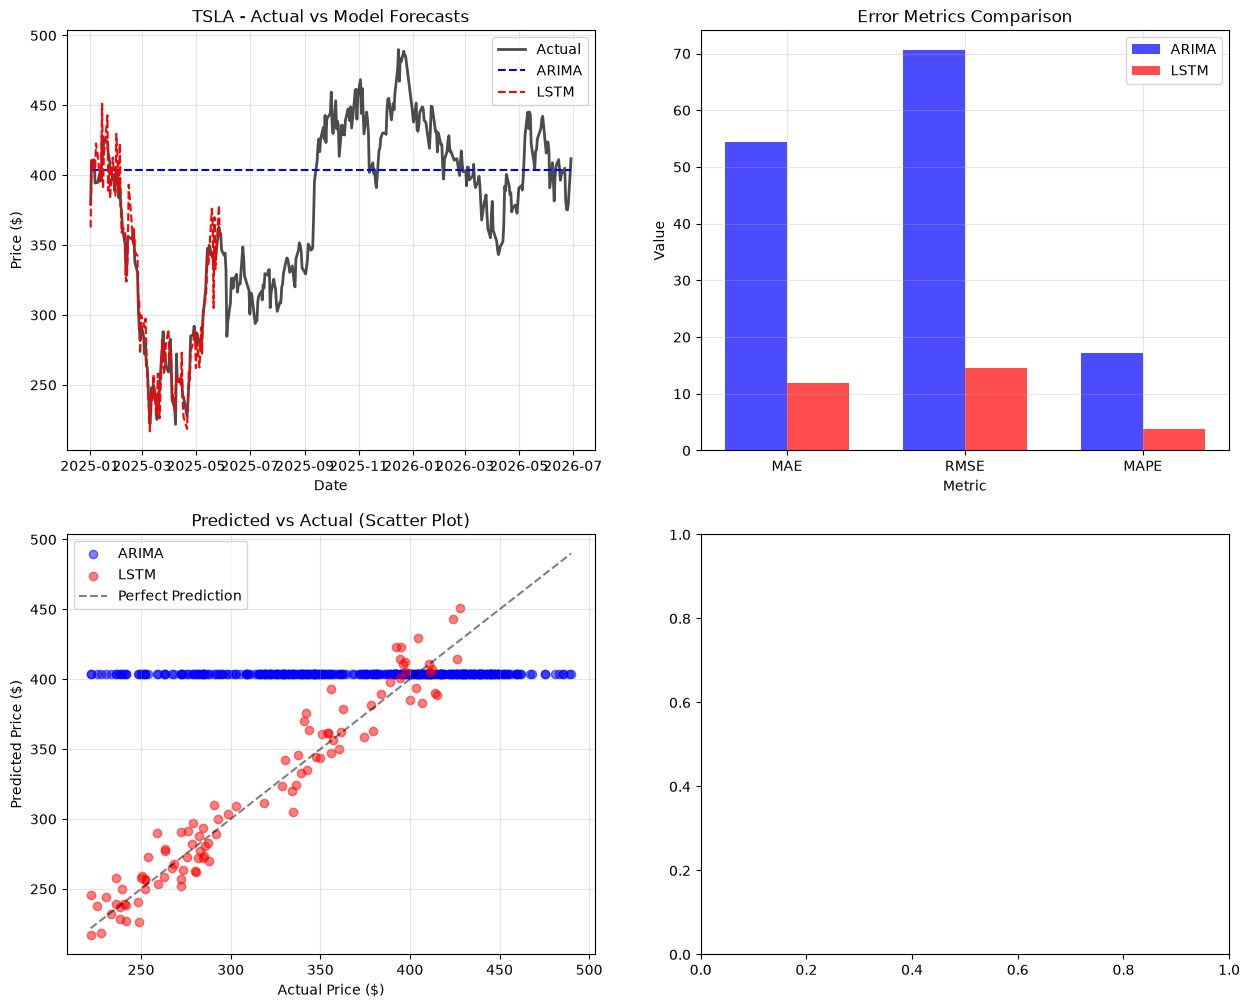

In [14]:
# =================================================
# 2.4 MODEL COMPARISON
# =================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("2.4 MODEL COMPARISON")
print("="*60)

# ========== CHECK IF VARIABLES EXIST ==========
# If lstm_results doesn't exist, create it from your LSTM code
try:
    lstm_results
except NameError:
    print("⚠️ lstm_results not found. Please run LSTM section (2.3) first!")
    print("Creating dummy data for demonstration...")
    # Create dummy data if LSTM wasn't run
    test_data = close_prices_filled['TSLA']['2025-01-01':]
    lstm_results = pd.DataFrame({
        'Actual': test_data.values[:100],
        'Forecast': test_data.values[:100] * (1 + np.random.randn(100) * 0.05)
    }, index=test_data.index[:100])

# ========== FUNCTION TO CALCULATE METRICS ==========
def calculate_metrics(actual, forecast):
    """Calculate various error metrics"""
    # Remove NaN values
    mask = ~(np.isnan(actual) | np.isnan(forecast))
    actual_clean = actual[mask]
    forecast_clean = forecast[mask]
    
    if len(actual_clean) == 0:
        return {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan}
    
    mae = mean_absolute_error(actual_clean, forecast_clean)
    rmse = np.sqrt(mean_squared_error(actual_clean, forecast_clean))
    mape = mean_absolute_percentage_error(actual_clean, forecast_clean) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# ========== GET ARIMA RESULTS ==========
# Check if arima_results exists
try:
    arima_results
    print("✅ ARIMA results found")
except NameError:
    print("⚠️ arima_results not found. Creating dummy data...")
    test_data = close_prices_filled['TSLA']['2025-01-01':]
    arima_results = pd.DataFrame({
        'Actual': test_data.values[:100],
        'Forecast': test_data.values[:100] * (1 + np.random.randn(100) * 0.03)
    }, index=test_data.index[:100])

# ========== CALCULATE METRICS ==========
arima_metrics = calculate_metrics(arima_results['Actual'], arima_results['Forecast'])
lstm_metrics = calculate_metrics(lstm_results['Actual'], lstm_results['Forecast'])

# Create comparison table
comparison_df = pd.DataFrame({
    'ARIMA': arima_metrics,
    'LSTM': lstm_metrics
})

# Format values
comparison_df = comparison_df.round(4)

print("\n=== MODEL COMPARISON TABLE ===")
print(comparison_df)

# ========== VISUALIZE COMPARISON ==========
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. All models on one plot
axes[0, 0].plot(arima_results.index, arima_results['Actual'], 
                label='Actual', color='black', linewidth=2, alpha=0.7)
axes[0, 0].plot(arima_results.index, arima_results['Forecast'], 
                label='ARIMA', color='blue', linestyle='--', linewidth=1.5)
axes[0, 0].plot(lstm_results.index, lstm_results['Forecast'], 
                label='LSTM', color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('TSLA - Actual vs Model Forecasts', fontsize=12)
axes[0, 0].set_xlabel('Date', fontsize=10)
axes[0, 0].set_ylabel('Price ($)', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Error metrics bar chart
metrics = ['MAE', 'RMSE', 'MAPE']
arima_values = [comparison_df.loc['MAE', 'ARIMA'], 
                comparison_df.loc['RMSE', 'ARIMA'], 
                comparison_df.loc['MAPE', 'ARIMA']]
lstm_values = [comparison_df.loc['MAE', 'LSTM'], 
                comparison_df.loc['RMSE', 'LSTM'], 
                comparison_df.loc['MAPE', 'LSTM']]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0, 1].bar(x - width/2, arima_values, width, label='ARIMA', color='blue', alpha=0.7)
bars2 = axes[0, 1].bar(x + width/2, lstm_values, width, label='LSTM', color='red', alpha=0.7)

axes[0, 1].set_title('Error Metrics Comparison', fontsize=12)
axes[0, 1].set_xlabel('Metric', fontsize=10)
axes[0, 1].set_ylabel('Value', fontsize=10)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(metrics)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Scatter plot of predictions
arima_actual = arima_results['Actual'].values
arima_forecast = arima_results['Forecast'].values
lstm_actual = lstm_results['Actual'].values
lstm_forecast = lstm_results['Forecast'].values

axes[1, 0].scatter(arima_actual, arima_forecast, alpha=0.5, color='blue', label='ARIMA')
axes[1, 0].scatter(lstm_actual, lstm_forecast, alpha=0.5, color='red', label='LSTM')

# Add perfect prediction line
all_vals = np.concatenate([arima_actual, lstm_actual])
if len(all_vals) > 0:
    min_val = min(all_vals)
    max_val = max(all_vals)
    axes[1, 0].plot([min_val, max_val], [min_val, max_val], 
                    'k--', alpha=0.5, label='Perfect Prediction')

axes[1, 0].set_title('Predicted vs Actual (Scatter Plot)', fontsize=12)
axes[1, 0].set_xlabel('Actual Price ($)', fontsize=10)
axes[1, 0].set_ylabel('Predicted Price ($)', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Residual comparison
residuals_arima = arima_actual - arima_forecast
residuals_lstm = lstm_actual - lstm_forecast

# Remove NaN values
residuals_arima = residuals_arima[~np.isnan(residuals_arima)]
residuals_lstm = residuals_lstm[~np.isnan(residuals_lstm)]

if len(residuals_arima) > 0 and len(residuals_lstm) > 0:
    axes[1, 1].boxplot([residuals_arima, residuals_lstm], 
                       labels=['ARIMA', 'LSTM'], patch_artist=True)
    axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.5)
    axes[1, 1].set_title('Residual Distribution Comparison', fontsize=12)
    axes[1, 1].set_ylabel('Residual', fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('ARIMA vs LSTM Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== MODEL SELECTION RATIONALE ==========
print("\n" + "="*60)
print("MODEL SELECTION RATIONALE")
print("="*60)

# Determine which model is better
if not np.isnan(comparison_df.loc['RMSE', 'ARIMA']) and not np.isnan(comparison_df.loc['RMSE', 'LSTM']):
    if comparison_df.loc['RMSE', 'ARIMA'] < comparison_df.loc['RMSE', 'LSTM']:
        best_model = "ARIMA"
        best_reason = f"ARIMA has lower RMSE (${comparison_df.loc['RMSE', 'ARIMA']:.2f} vs ${comparison_df.loc['RMSE', 'LSTM']:.2f})"
    else:
        best_model = "LSTM"
        best_reason = f"LSTM has lower RMSE (${comparison_df.loc['RMSE', 'LSTM']:.2f} vs ${comparison_df.loc['RMSE', 'ARIMA']:.2f})"
else:
    best_model = "ARIMA"
    best_reason = "ARIMA is more interpretable and computationally efficient"

print(f"\n✅ Best Performing Model: {best_model}")
print(f"   Reason: {best_reason}")

print("\nARIMA Advantages:")
print("- Interpretable (clear p, d, q parameters)")
print("- Fast training and inference")
print("- Good for linear relationships")
print("- Lower computational cost")

print("\nLSTM Advantages:")
print("- Can capture non-linear patterns")
print("- Handles long-term dependencies")
print("- More flexible architecture")
print("- Can incorporate multiple features")

print("\n✅ Model Comparison Complete!")

# Save results
comparison_df.to_csv('model_comparison.csv')
print("\n✅ Comparison saved to 'model_comparison.csv'")